# Trying out a custom model for gate keypoint

Plan is to take a good backbone (mobilenetV4) and attach a custom head (keypoint detection)

Rational for doing this is to get the best speed and accuracy.

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!rsync '/content/drive/MyDrive/Vision/dataset/yolo/gate_yolo.zip' /
!cp '/content/drive/MyDrive/Vision/dataset/yolo/data.yaml' .
!unzip /gate_yolo.zip -d dataset

Archive:  /gate_yolo.zip
replace /content/dataset/__MACOSX/._images? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
  inflating: /content/dataset/images/ARVP_Front_front_2025-08-12_19-56-09_UTC_111690877.jpeg  
replace /content/dataset/__MACOSX/images/._ARVP_Front_front_2025-08-12_19-56-09_UTC_111690877.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/dataset/__MACOSX/images/._ARVP_Front_front_2025-08-12_19-56-09_UTC_111690877.jpeg  
  inflating: /content/dataset/images/AUV-IITB_Gate_Task_1755012488_558786_jpg.rf.6dfcfae1b652d0d439b2a0758fd3e83c.jpg  
  inflating: /content/dataset/__MACOSX/images/._AUV-IITB_Gate_Task_1755012488_558786_jpg.rf.6dfcfae1b652d0d439b2a0758fd3e83c.jpg  
  inflating: /content/dataset/images/ARVP_Front_front_2025-08-12_22-21-47_UTC_15511967.jpeg  
  inflating: /content/dataset/__MACOSX/images/._ARVP_Front_front_2025-08-12_22-21-47_UTC_15511967.jpeg  
  inflating: /content/dataset/images/Cabrillo_Robotics_Club_gate6_gate42.png  
  inflating: /content

In [1]:
import os
import random
import shutil
import sys
import cv2
import torch
import timm
import torch.nn as nn
import numpy as np
import albumentations as A
from pathlib import Path
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset

parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))
from tools.inference import visualize

/Users/ziqiangzhu/sys-arch-2026/Vision/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Make a model

In [2]:
timm.list_models("*mobilenetv4*")

['mobilenetv4_conv_aa_large',
 'mobilenetv4_conv_aa_medium',
 'mobilenetv4_conv_blur_medium',
 'mobilenetv4_conv_large',
 'mobilenetv4_conv_medium',
 'mobilenetv4_conv_small',
 'mobilenetv4_conv_small_035',
 'mobilenetv4_conv_small_050',
 'mobilenetv4_hybrid_large',
 'mobilenetv4_hybrid_large_075',
 'mobilenetv4_hybrid_medium',
 'mobilenetv4_hybrid_medium_075']

In [3]:
variants = timm.list_pretrained("*mobilenetv4*")
for v in variants:
  print(v)

mobilenetv4_conv_aa_large.e230_r384_in12k
mobilenetv4_conv_aa_large.e230_r384_in12k_ft_in1k
mobilenetv4_conv_aa_large.e230_r448_in12k_ft_in1k
mobilenetv4_conv_aa_large.e600_r384_in1k
mobilenetv4_conv_blur_medium.e500_r224_in1k
mobilenetv4_conv_large.e500_r256_in1k
mobilenetv4_conv_large.e600_r384_in1k
mobilenetv4_conv_medium.e180_ad_r384_in12k
mobilenetv4_conv_medium.e180_r384_in12k
mobilenetv4_conv_medium.e250_r384_in12k
mobilenetv4_conv_medium.e250_r384_in12k_ft_in1k
mobilenetv4_conv_medium.e500_r224_in1k
mobilenetv4_conv_medium.e500_r256_in1k
mobilenetv4_conv_small.e1200_r224_in1k
mobilenetv4_conv_small.e2400_r224_in1k
mobilenetv4_conv_small.e3600_r256_in1k
mobilenetv4_conv_small_050.e3000_r224_in1k
mobilenetv4_hybrid_large.e600_r384_in1k
mobilenetv4_hybrid_large.ix_e600_r384_in1k
mobilenetv4_hybrid_medium.e200_r256_in12k
mobilenetv4_hybrid_medium.e200_r256_in12k_ft_in1k
mobilenetv4_hybrid_medium.e500_r224_in1k
mobilenetv4_hybrid_medium.ix_e550_r256_in1k
mobilenetv4_hybrid_medium.ix

In [4]:
backbone =  timm.create_model(
      'mobilenetv4_conv_small.e2400_r224_in1k',
      pretrained=True,
      features_only=True,
  )

# This will print the reduction (stride), channels, and module name for ALL stages
for stage in backbone.feature_info:
  print(f"Stage {stage['index']}:")
  print(f"  Reduction: {stage['reduction']}x")
  print(f"  Channels:  {stage['num_chs']}")
  print(f"  Module:    {stage['module']}")
  print("-" * 20)

Unexpected keys (norm_head.num_batches_tracked, classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Stage 0:
  Reduction: 2x
  Channels:  32
  Module:    bn1
--------------------
Stage 1:
  Reduction: 4x
  Channels:  32
  Module:    blocks.0
--------------------
Stage 2:
  Reduction: 8x
  Channels:  64
  Module:    blocks.1
--------------------
Stage 3:
  Reduction: 16x
  Channels:  96
  Module:    blocks.2
--------------------
Stage 4:
  Reduction: 32x
  Channels:  960
  Module:    blocks.4
--------------------


In [5]:
# Load the hybrid backbone for high-quality spatial features
backbone = timm.create_model(
    "mobilenetv4_conv_small.e2400_r224_in1k",
    pretrained=True,
    features_only=True,
)

img = torch.randn(1, 3, 384, 384)
out = backbone(img)

for o in out:
  print(o.shape)

Unexpected keys (norm_head.num_batches_tracked, classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


torch.Size([1, 32, 192, 192])
torch.Size([1, 32, 96, 96])
torch.Size([1, 64, 48, 48])
torch.Size([1, 96, 24, 24])
torch.Size([1, 960, 12, 12])


In [6]:
class SingleObjectKeypointDetector(nn.Module):
  def __init__(self, num_keypoints=4):
    super().__init__()

    self.backbone = timm.create_model(
        'mobilenetv4_conv_small.e2400_r224_in1k',
        pretrained=True,
        features_only=True,
    )

    last_channel_count = self.backbone.feature_info[-1]['num_chs']

    self.head = nn.Sequential(
        nn.Conv2d(last_channel_count, 128, kernel_size=1),
        nn.BatchNorm2d(128),
        nn.ReLU6(inplace=True),

        nn.Conv2d(128, 128, kernel_size=3, padding=1, groups=1),
        nn.BatchNorm2d(128),
        nn.ReLU6(inplace=True),

        nn.Flatten(),

        nn.Linear(128 * 7 * 7, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_keypoints * 2)
    )

    nn.init.normal_(self.head[-1].weight, mean=0, std=0.01)

  def forward(self, x):
    features = self.backbone(x)[-1]
    coords = self.head(features)

    return coords.view(-1, coords.shape[1] // 2, 2)

In [7]:
model = SingleObjectKeypointDetector()
input_tensor = torch.randn(1, 3, 224, 224)
output = model(input_tensor)
print(output.shape)

Unexpected keys (norm_head.num_batches_tracked, classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


torch.Size([1, 4, 2])


## Training

Training a custom keypoint detector. Use the mobilenetV4 backend, with a custom head output 10 keypoints and confidence score for each keypoint.

### Loss function

In [ ]:
import math

class WingLoss(nn.Module):
  def __init__(self, w=10.0, epsilon=2.0):
    super(WingLoss, self).__init__()
    self.w = w
    self.epsilon = epsilon
    self.C = self.w - self.w * math.log(1 + w / epsilon)

  def forward(self, pred, target, mask):
    # pred, target shape: [Batch, N, 2]
    # mask shape:         [Batch, N, 1]

    diff = target - pred
    abs_diff = diff.abs()

    # Wing Loss Calculation
    is_small_error = abs_diff < self.w
    loss_small = self.w * torch.log(1 + abs_diff / self.epsilon)
    loss_large = abs_diff - self.C
    raw_loss = torch.where(is_small_error, loss_small, loss_large)

    # --- APPLY MASK ---
    # Expand mask to [Batch, N, 2] so it applies to both x and y errors
    if mask.dim() == 2:
      mask = mask.unsqueeze(-1)
    mask_expanded = mask.expand_as(raw_loss)

    masked_loss = raw_loss * mask_expanded

    # Normalize by number of visible elements to keep loss scale consistent
    # Add epsilon to avoid division by zero if all points are invisible
    num_visible_elements = mask_expanded.sum() + 1e-6

    return masked_loss.sum() / num_visible_elements

### Dataset input

In [ ]:
def load_yolo_dataset(root_path, split='train'):
    images_dir = os.path.join(root_path, split, 'images')
    labels_dir = os.path.join(root_path, split, 'labels')

    samples = []

    # List all image files
    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

    for img_file in tqdm(image_files, desc=f"Loading {split} data"):
        img_path = os.path.join(images_dir, img_file)

        # Construct corresponding label path
        label_name = os.path.splitext(img_file)[0] + '.txt'
        label_path = os.path.join(labels_dir, label_name)

        if not os.path.exists(label_path):
            continue

        # Load and Parse Label (YOLO format: class x y w h k1x k1y k1v ...)
        data = np.loadtxt(label_path)
        # Assuming 4 keypoints based on your previous cells
        raw_kpts = data[5:].reshape(-1, 3)

        visibility = raw_kpts[:, 2]

        samples.append({
            'image_path': img_path,
            'kpts_norm': raw_kpts[:, :2],
            'visibility': visibility
        })

    return samples

In [ ]:
class KeypointDataset(Dataset):
  def __init__(self, data_samples, transform=None, img_size=224) -> None:
    self.data = data_samples
    self.transform = transform
    self.img_size = img_size

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    sample = self.data[idx]

    image = cv2.imread(sample['image_path'])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    kpts_norm = sample['kpts_norm']
    kpts_px = kpts_norm * np.array([w, h])

    if self.transform:
      transformed = self.transform(image=image, keypoints=kpts_px)
      image = transformed['image']
      keypoints = transformed['keypoints']

    keypoints = np.array(keypoints, dtype=np.float32)
    keypoints[:,0] /= self.img_size
    keypoints[:,1] /= self.img_size

    visibility = sample['visibility']

    for i, (x, y) in enumerate(keypoints):
      if (not (0.0 <= x <= 1.0 and 0.0 <= y <= 1.0)) or visibility[i] != 2:
        visibility[i] = 0.0

    return image, torch.tensor(keypoints), torch.tensor(visibility)

In [ ]:
def get_train_transforms(img_size=224):
  return A.Compose([
      A.Resize(img_size, img_size),

      A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.2, rotate_limit=30, p=0.8),
      A.Perspective(scale=(0.05, 0.1), p=0.5),

      A.RandomBrightnessContrast(p=0.5),
      A.GaussNoise(p=0.2),

      A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
      ToTensorV2()
  ], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

def get_val_transforms(img_size=224):
  return A.Compose([
      A.Resize(img_size, img_size),
      A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
      ToTensorV2()
  ], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

### Show augmentation

Original Image Shape: (720, 1280, 3)
Original Keypoints:
 [[640.      360.     ]
 [640.      360.     ]
 [802.11968 385.68024]
 [640.      360.     ]]


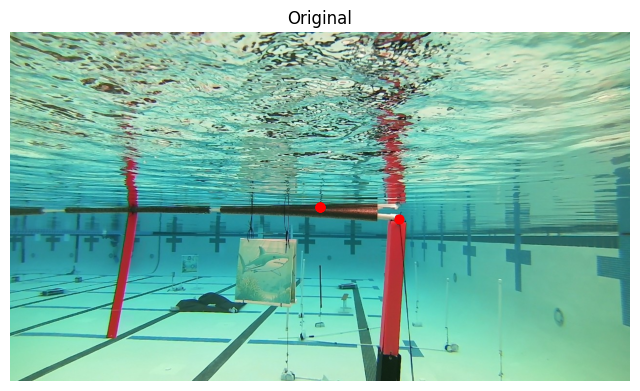

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Transformed Image Shape: (224, 224, 3)
Transformed Keypoints:
 [[118.87216  124.227135]
 [118.87216  124.227135]
 [147.74373  131.87296 ]
 [118.87216  124.227135]]


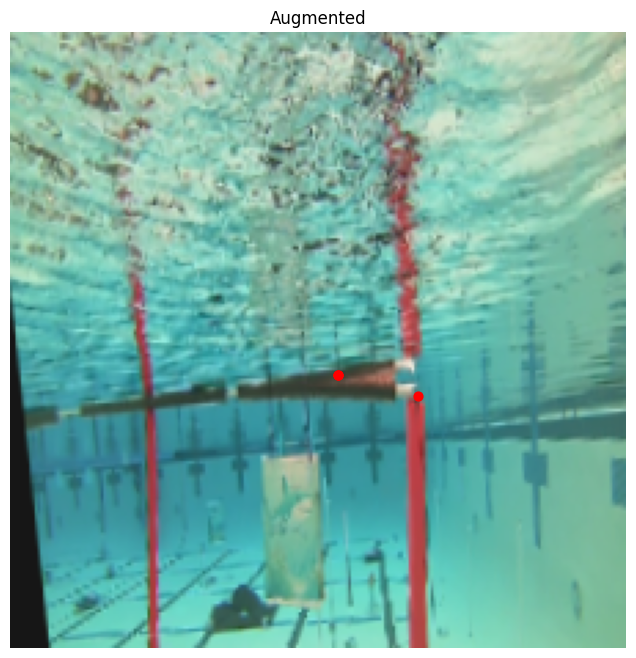

In [ ]:
import matplotlib.pyplot as plt
import os

# 1. Pick a sample
img_path = '../dataset/train/images/ARVP_Front_front_2025-08-12_15-43-47_UTC_887444407.jpeg'
label_path = '../dataset/train/labels/ARVP_Front_front_2025-08-12_15-43-47_UTC_887444407.txt'

if os.path.exists(img_path) and os.path.exists(label_path):
    # Load image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    # Load and Parse Label (YOLO format: class x y w h k1x k1y k1v ...)
    data = np.loadtxt(label_path)
    # Assuming 4 keypoints based on your previous cells
    raw_kpts = data[5:].reshape(-1, 3)

    # Convert normalized (0-1) to absolute (pixels) for Albumentations
    kpts_absolute = raw_kpts[:, :2] * np.array([w, h])

    print("Original Image Shape:", image.shape)
    print("Original Keypoints:\n", kpts_absolute)

    # Visualize Original
    visualize(image, kpts_absolute, title="Original")

    # 2. Apply Augmentation
    transform = get_train_transforms(img_size=224)

    # Albumentations expects 'keypoints' as a list of (x, y)
    transformed = transform(image=image, keypoints=kpts_absolute)

    t_image = transformed['image']
    t_kpts = transformed['keypoints']

    # t_image is a Tensor (C, H, W) due to ToTensorV2, convert back to HWC for plotting
    t_image_np = t_image.permute(1, 2, 0).numpy()

    # Denormalize image color for visualization (approximate)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    t_image_vis = std * t_image_np + mean
    t_image_vis = np.clip(t_image_vis, 0, 1)

    print("Transformed Image Shape:", t_image_np.shape)
    print("Transformed Keypoints:\n", np.array(t_kpts))

    # Visualize Transformed
    visualize(t_image_vis, t_kpts, title="Augmented")
else:
    print("Sample file not found. Please check the path.")

### Training loop

In [ ]:
import torch.optim as optim
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  running_loss = 0.0

  loop = tqdm(loader, leave=True)

  for images, targets, masks in loop:
    images = images.to(device)
    targets = targets.to(device)
    masks = masks.to(device)

    preds = model(images)

    loss = criterion(preds, targets, masks)

    optimizer.zero_grad()
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

    optimizer.step()

    running_loss += loss.item()
    loop.set_description(f"Loss: {loss.item():.5f}")

  return running_loss / len(loader)

def validate(model, loader, criterion, device):
  model.eval()
  running_loss = 0.0

  with torch.no_grad():
    for images, targets, masks in loader:
      images = images.to(device)
      targets = targets.to(device)
      masks = masks.to(device)

      preds = model(images)
      loss = criterion(preds, targets, masks)

      running_loss += loss.item()

  return running_loss / len(loader)

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
LEARNING_RATE = 1e-4
EPOCHS = 50
NUM_KEYPOINTS = 4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = SingleObjectKeypointDetector(NUM_KEYPOINTS)
model = model.to(DEVICE)

train_samples = load_yolo_dataset('/content/dataset', split='train')
val_samples = load_yolo_dataset('/content/dataset', split='val')

print(f"Loaded {len(train_samples)} training samples")
print(f"Loaded {len(val_samples)} validation samples")

train_dataset = KeypointDataset(train_samples, transform=get_train_transforms(224))
val_dataset = KeypointDataset(val_samples, transform=get_val_transforms(224))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
criterion = WingLoss()

# 5. Learning Rate Scheduler (Cosine Annealing is great for convergence)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# 6. Run Training
print(f"Starting training on {DEVICE}...")

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss = validate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

    # Simple checkpointing
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"checkpoint_epoch_{epoch+1}.pth")

print("Training Complete.")

Loading val data: 100%|██████████| 149/149 [00:01<00:00, 98.20it/s]
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Loaded 587 training samples
Loaded 146 validation samples
Starting training on cpu...


Loss: 0.96079: 100%|██████████| 19/19 [00:50<00:00,  2.67s/it]


Epoch [1/50] Train Loss: 1.17094 | Val Loss: 1.65418


Loss: 0.62400: 100%|██████████| 19/19 [00:50<00:00,  2.66s/it]


...

Epoch [48/50] Train Loss: 0.32104 | Val Loss: 0.19552


Loss: 0.31863: 100%|██████████| 19/19 [00:49<00:00,  2.59s/it]


Epoch [49/50] Train Loss: 0.30725 | Val Loss: 0.19770


Loss: 0.36871: 100%|██████████| 19/19 [00:47<00:00,  2.50s/it]


Epoch [50/50] Train Loss: 0.32332 | Val Loss: 0.19516
Training Complete.


## Export Model

In [10]:
class ModelWithNormalization(nn.Module):
    def __init__(self, base_model):
        super(ModelWithNormalization, self).__init__()
        self.base_model = base_model

        # ImageNet Mean and Std constants
        # Reshaped to [1, 3, 1, 1] for broadcasting over a batch of images
        self.register_buffer(
            'mean',
            torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        )
        self.register_buffer(
            'std',
            torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        )

    def forward(self, x):
        # x is assumed to be a FloatTensor in range [0, 1]

        # 1. Normalize: (x - mean) / std
        x_normalized = (x - self.mean) / self.std

        # 2. Pass to actual model
        return self.base_model(x_normalized)

In [11]:
# --- USAGE SCRIPT ---

# 1. Instantiate your original model architecture
# (Make sure this class is defined or imported)
original_model = SingleObjectKeypointDetector(num_keypoints=4)

# 2. Load your trained weights
checkpoint_path = "../checkpoint_epoch_50.pth"

# Handle case where checkpoint is a dict (often contains 'state_dict', 'optimizer', etc.)
# or just the weights directly.
checkpoint = torch.load(checkpoint_path, map_location='cpu')
if 'state_dict' in checkpoint:
    original_model.load_state_dict(checkpoint['state_dict'])
else:
    original_model.load_state_dict(checkpoint)

original_model.eval()

# 3. Wrap it
final_model = ModelWithNormalization(original_model)
final_model.eval()

# 4. Save the wrapped model
# Option A: Standard PyTorch save (requires source code to load)
torch.save(final_model.state_dict(), "../model_with_norm.pth")

# Option B: TorchScript (Recommended for Deployment/C++/Mobile)
# This bakes the logic into a standalone file that doesn't need the Python class definitions
try:
    dummy_input = torch.randn(1, 3, 224, 224)
    traced_model = torch.jit.trace(final_model, dummy_input)
    traced_model.save("model_with_norm_traced.pt")
    print("Success: Saved traced model to model_with_norm_traced.pt")
except Exception as e:
    print(f"Tracing failed (common if you use dynamic control flow): {e}")

Unexpected keys (norm_head.num_batches_tracked, classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Success: Saved traced model to model_with_norm_traced.pt


## Give it a try

In [14]:
try:
    model = torch.jit.load("../model_with_norm_traced.pt")
    model.eval()
except Exception as e:
    print(f"Error loading model: {e}")

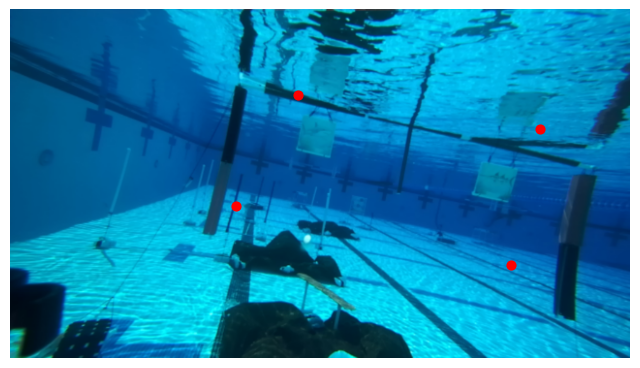

In [15]:
raw_img = cv2.imread("../dataset/train/images/Cabrillo_Robotics_Club_gate3_gate1.png")
h, w, _ = raw_img.shape
img = cv2.resize(raw_img, (224, 224))
img = img.astype('float32') / 255.0

tensor_img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)

preds = model(tensor_img)
kpts_norm = preds.detach().cpu().numpy().reshape(-1,2)
kpts_absolute = kpts_norm * np.array([w, h])

visualize(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB), kpts_absolute)